In [1]:
import pandas as pd
import numpy as np
import time
import pickle
import warnings
warnings.filterwarnings('ignore')
import os

# Prétraitement & split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# ML Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [2]:
# ========================================
# CONFIGURATION
# ========================================

INPUT_FILE = "archive/full_df_binary_labels.csv"
BASE_MODEL_DIR = "trained_models/ml_optimized/feature_importance/"
TEST_SIZE = 0.2
RANDOM_STATE = 42
SAVE_MODELS = True

# ========================================
# FEATURE IMPORTANCE CONFIGURATION
# ========================================
# Option: Number of top features to keep
TOP_K_FEATURES = 30  # Conserver les 30 features les plus importantes

print(f"🎯 Feature Importance Configuration: top {TOP_K_FEATURES} features")

# ========================================
# PER-MODEL DATASET SIZE CONTROL
# ========================================

MODEL_SAMPLE_SIZES = {
    'Random Forest': None,        # Fast - use full dataset
    'Decision Tree': None,        # Fast - use full dataset
    'XGBoost': None,              # Fast - use full dataset ⭐ BEST MODEL
    'KNN': 50000,                 # SLOW - use only 50k rows
    'SVM': 100000,                # VERY SLOW - use only 100k rows
    'Naive Bayes': None           # Fast - use full dataset
}

print("\n📊 Per-Model Sample Sizes:")
for model, size in MODEL_SAMPLE_SIZES.items():
    size_str = 'Full dataset' if size is None else f'{size:,} rows'
    marker = ' ⭐' if model == 'XGBoost' else ''
    print(f"   {model}: {size_str}{marker}")

# Create base directory
os.makedirs(BASE_MODEL_DIR, exist_ok=True)
print(f"\n✅ Base model directory: {BASE_MODEL_DIR}")
print(f"\n🎯 Optimization Method: Feature Importance (top {TOP_K_FEATURES} features)")


🎯 Feature Importance Configuration: top 30 features

📊 Per-Model Sample Sizes:
   Random Forest: Full dataset
   Decision Tree: Full dataset
   XGBoost: Full dataset ⭐
   KNN: 50,000 rows
   SVM: 100,000 rows
   Naive Bayes: Full dataset

✅ Base model directory: trained_models/ml_optimized/feature_importance/

🎯 Optimization Method: Feature Importance (top 30 features)


In [3]:
# ========================================
# LOAD DATASET (Memory-Efficient)
# ========================================

CHUNK_SIZE = 100000
MAX_ROWS = None  # None = load all data, or set a limit

chunks = []
total_rows = 0

print("⏳ Reading data...")
for i, chunk in enumerate(pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE)):
    if MAX_ROWS and total_rows >= MAX_ROWS:
        break
    
    if MAX_ROWS and total_rows + len(chunk) > MAX_ROWS:
        chunk = chunk.head(MAX_ROWS - total_rows)
    
    chunks.append(chunk)
    total_rows += len(chunk)
    
    if (i + 1) % 5 == 0:
        print(f"   Loaded chunk {i+1}: {total_rows:,} rows total")

print(f"\n✅ Loaded {len(chunks)} chunks")
print(f"✅ Total rows: {total_rows:,}")

print("\n🔗 Combining chunks...")
df_full = pd.concat(chunks, ignore_index=True)
del chunks

print(f"✅ Dataset shape: {df_full.shape}")
print(f"✅ Columns: {len(df_full.columns)}")

⏳ Reading data...
   Loaded chunk 5: 500,000 rows total
   Loaded chunk 10: 1,000,000 rows total
   Loaded chunk 15: 1,500,000 rows total
   Loaded chunk 20: 2,000,000 rows total
   Loaded chunk 25: 2,500,000 rows total
   Loaded chunk 30: 3,000,000 rows total
   Loaded chunk 35: 3,500,000 rows total
   Loaded chunk 40: 4,000,000 rows total
   Loaded chunk 45: 4,500,000 rows total
   Loaded chunk 50: 5,000,000 rows total
   Loaded chunk 55: 5,500,000 rows total
   Loaded chunk 60: 6,000,000 rows total
   Loaded chunk 65: 6,500,000 rows total
   Loaded chunk 70: 7,000,000 rows total
   Loaded chunk 75: 7,500,000 rows total
   Loaded chunk 80: 8,000,000 rows total
   Loaded chunk 85: 8,500,000 rows total
   Loaded chunk 90: 9,000,000 rows total
   Loaded chunk 95: 9,500,000 rows total
   Loaded chunk 100: 10,000,000 rows total
   Loaded chunk 105: 10,500,000 rows total
   Loaded chunk 110: 11,000,000 rows total
   Loaded chunk 115: 11,500,000 rows total
   Loaded chunk 120: 12,000,000 ro

In [4]:
#=========================================
# SEPARATE FEATURES AND TARGET
# ========================================

label_columns = ['Label', 'Label_Binary']
existing_labels = [col for col in label_columns if col in df_full.columns]

# Features et target
X_full = df_full.drop(columns=existing_labels)
y_full = df_full['Label_Binary']

print(f"✅ Features (X): {X_full.shape}")
print(f"✅ Target (y): {y_full.shape}")
print(f"\n📊 Total features: {X_full.shape[1]}")

✅ Features (X): (16232943, 57)
✅ Target (y): (16232943,)

📊 Total features: 57


In [5]:
# ========================================
# DEFINE MODELS
# ========================================

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=1
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1
    ),
    'SVM': SVC(
        kernel='rbf',
        random_state=RANDOM_STATE,
        verbose=True
    ),
    'Naive Bayes': GaussianNB()
}

print(f"✅ Defined {len(models)} models")


✅ Defined 6 models


In [6]:
# ========================================
# HELPER FUNCTIONS (Feature Importance)
# ========================================

from sklearn.metrics import confusion_matrix

def calculate_far(y_true, y_pred):
    """
    Calculate False Alert Rate (FAR)
    FAR = FP / (FP + TN)
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    far = fp / (fp + tn) if (fp + tn) > 0 else 0
    return far


def get_model_data(X_full, y_full, model_name, sample_size, test_size, random_state, feature_selection=None):
    """
    Get train/test split with optional sampling.
    feature_selection: list of selected feature names (top features)
    """
    # Appliquer la sélection de features si fournie
    if feature_selection is not None:
        X_full = X_full[feature_selection]
        print(f"🔹 Using {len(feature_selection)} selected features based on importance")
    
    # Gestion du sampling
    if sample_size is None:
        X = X_full
        y = y_full
        print(f"📊 Using FULL dataset: {len(X):,} rows")
    else:
        if sample_size > len(X_full):
            print(f"⚠️ Requested {sample_size:,} rows but only {len(X_full):,} available")
            X = X_full
            y = y_full
        else:
            print(f"📊 Sampling {sample_size:,} rows from {len(X_full):,} total (stratified)")
            X, _, y, _ = train_test_split(
                X_full, y_full,
                train_size=sample_size,
                random_state=random_state,
                stratify=y_full
            )
    
    # Split train/test
    print(f"🔪 Splitting into train/test ({test_size*100:.0f}% test)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    
    print(f"✅ Train set: {X_train.shape[0]:,} samples")
    print(f"✅ Test set: {X_test.shape[0]:,} samples")
    
    return X_train, X_test, y_train, y_test


In [7]:
# ========================================
# TRAIN AND TEST ALL MODELS WITH FEATURE IMPORTANCE
# ========================================

results = {}
trained_models = {}
scalers = {}
selected_features_dict = {}

# Nombre de top features à sélectionner
TOP_N_FEATURES = 30  # Ajustable selon ton dataset

for model_name, model in models.items():
    print("\n" + "="*80)
    print(f"🚀 TRAINING: {model_name} WITH FEATURE IMPORTANCE")
    print("="*80)
    
    model_dir = os.path.join(BASE_MODEL_DIR, model_name.lower().replace(' ', '_'), '')
    os.makedirs(model_dir, exist_ok=True)
    print(f"📁 Model directory: {model_dir}")
    
    sample_size = MODEL_SAMPLE_SIZES.get(model_name)
    
    # ========================================
    # 🎯 STEP 0: Initial train/test split (full features)
    # ========================================
    X_train, X_test, y_train, y_test = get_model_data(
        X_full, y_full,
        model_name,
        sample_size,
        TEST_SIZE,
        RANDOM_STATE
    )
    
    # ========================================
    # 🎯 STEP 1: Standardize features (optional for tree-based models)
    # ========================================
    print(f"\n⚖️ Step 1: Standardizing features (optional for tree-based models)...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Sauvegarder le scaler
    scalers[model_name] = scaler
    
    # ========================================
    # 🎯 STEP 2: Fit model for feature importance
    # ========================================
    print(f"\n🔬 Step 2: Fit model to compute feature importance...")
    
    # Certains modèles comme SVM ou KNN n'ont pas feature_importances_ directement
    if hasattr(model, "fit") and hasattr(model, "feature_importances_") is False:
        # Pour SVM, KNN, Naive Bayes, on peut utiliser RandomForest temporaire pour sélectionner features
        temp_model = RandomForestClassifier(n_estimators=10, random_state=RANDOM_STATE, n_jobs=-1)
        temp_model.fit(X_train_scaled, y_train)
        importances = temp_model.feature_importances_
    else:
        model.fit(X_train_scaled, y_train)
        importances = model.feature_importances_
    
    # Sélection des top N features
    top_idx = np.argsort(importances)[::-1][:TOP_N_FEATURES]
    top_features = X_train.columns[top_idx]
    selected_features_dict[model_name] = top_features
    print(f"✅ Top {TOP_N_FEATURES} features selected: {list(top_features)}")
    
    # ========================================
    # 🎯 STEP 3: Re-train model with top features
    # ========================================
    X_train_sel = X_train_scaled[:, top_idx]
    X_test_sel = X_test_scaled[:, top_idx]
    
    print(f"\n⏱️ Training model on top features...")
    start_time = time.time()
    model.fit(X_train_sel, y_train)
    train_time = time.time() - start_time
    print(f"✅ Training completed in {train_time:.2f} seconds ({train_time/60:.2f} min)")
    
    # Prediction
    start_time = time.time()
    y_pred = model.predict(X_test_sel)
    pred_time = time.time() - start_time
    print(f"✅ Predictions completed in {pred_time:.2f} seconds")
    
    # Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary')
    recall = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')
    cm = confusion_matrix(y_test, y_pred)
    far = calculate_far(y_test, y_pred)
    
    # Stocker les résultats
    results[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'far': far,
        'train_time': train_time,
        'pred_time': pred_time,
        'confusion_matrix': cm,
        'predictions': y_pred,
        'sample_size': len(X_train) + len(X_test),
        'train_samples': len(X_train),
        'test_samples': len(X_test),
        'optimization': 'Feature Importance',
        'top_features': TOP_N_FEATURES
    }
    
    trained_models[model_name] = model
    
    # Affichage
    print(f"\n📊 RESULTS WITH FEATURE IMPORTANCE:")
    print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   FAR:       {far:.4f} ({far*100:.2f}%) ⭐ Key Metric!")
    print(f"\n🎯 Confusion Matrix:")
    print(cm)
    
    # Sauvegarde modèle
    if SAVE_MODELS:
        with open(os.path.join(model_dir, 'model.pkl'), 'wb') as f:
            pickle.dump(model, f)
        
        metadata = {
            'model_name': model_name,
            'optimization': 'Feature Importance',
            'top_features': TOP_N_FEATURES,
            'train_samples': len(X_train),
            'test_samples': len(X_test),
            'metrics': {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1_score': f1,
                'far': far
            }
        }
        with open(os.path.join(model_dir, 'metadata.pkl'), 'wb') as f:
            pickle.dump(metadata, f)
        print(f"💾 Model & metadata saved")

print("\n" + "="*80)
print("✅ ALL MODELS TRAINED & TESTED WITH FEATURE IMPORTANCE!")
print("="*80)



🚀 TRAINING: Random Forest WITH FEATURE IMPORTANCE
📁 Model directory: trained_models/ml_optimized/feature_importance/random_forest\
📊 Using FULL dataset: 16,232,943 rows
🔪 Splitting into train/test (20% test)...
✅ Train set: 12,986,354 samples
✅ Test set: 3,246,589 samples

⚖️ Step 1: Standardizing features (optional for tree-based models)...

🔬 Step 2: Fit model to compute feature importance...
✅ Top 30 features selected: ['Init Fwd Win Byts', 'Fwd Seg Size Min', 'TotLen Fwd Pkts', 'Dst Port', 'Subflow Fwd Byts', 'Fwd Header Len', 'Fwd Pkts/s', 'Fwd Pkt Len Max', 'Flow Pkts/s', 'Init Bwd Win Byts', 'Fwd IAT Tot', 'Fwd Seg Size Avg', 'Fwd IAT Max', 'Bwd Pkts/s', 'Flow Duration', 'Pkt Len Var', 'Pkt Len Max', 'Fwd Pkt Len Std', 'ACK Flag Cnt', 'Tot Fwd Pkts', 'Subflow Bwd Byts', 'Subflow Bwd Pkts', 'Bwd Pkt Len Std', 'Tot Bwd Pkts', 'Bwd Header Len', 'TotLen Bwd Pkts', 'Flow IAT Max', 'Flow IAT Min', 'Bwd Pkt Len Mean', 'Flow IAT Mean']

⏱️ Training model on top features...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  9.3min finished


✅ Training completed in 562.13 seconds (9.37 min)


[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    1.3s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    7.1s finished


✅ Predictions completed in 7.81 seconds

📊 RESULTS WITH FEATURE IMPORTANCE:
   Accuracy:  0.9889 (98.89%)
   Precision: 0.9887
   Recall:    0.9451
   F1-Score:  0.9664
   FAR:       0.0022 (0.22%) ⭐ Key Metric!

🎯 Confusion Matrix:
[[2691008    5934]
 [  30195  519452]]
💾 Model & metadata saved

🚀 TRAINING: Decision Tree WITH FEATURE IMPORTANCE
📁 Model directory: trained_models/ml_optimized/feature_importance/decision_tree\
📊 Using FULL dataset: 16,232,943 rows
🔪 Splitting into train/test (20% test)...
✅ Train set: 12,986,354 samples
✅ Test set: 3,246,589 samples

⚖️ Step 1: Standardizing features (optional for tree-based models)...

🔬 Step 2: Fit model to compute feature importance...
✅ Top 30 features selected: ['Init Fwd Win Byts', 'Fwd Seg Size Min', 'TotLen Fwd Pkts', 'Dst Port', 'Subflow Fwd Byts', 'Fwd Header Len', 'Fwd Pkts/s', 'Fwd Pkt Len Max', 'Flow Pkts/s', 'Init Bwd Win Byts', 'Fwd IAT Tot', 'Fwd Seg Size Avg', 'Fwd IAT Max', 'Bwd Pkts/s', 'Flow Duration', 'Pkt Len Var', 

In [8]:
print("\n" + "="*100)
print("📊 FINAL RESULTS SUMMARY - FEATURE IMPORTANCE Optimization")
print("="*100)

results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1_score'] for m in results.keys()],
    'FAR': [results[m]['far'] for m in results.keys()],
    'Train Time (s)': [results[m]['train_time'] for m in results.keys()],
    'Top Features': [results[m]['top_features'] for m in results.keys()],
    'Samples': [results[m]['sample_size'] for m in results.keys()]
})

# Trier par accuracy
results_df = results_df.sort_values('Accuracy', ascending=False)
results_df['Accuracy %'] = (results_df['Accuracy'] * 100).round(4)
results_df['FAR %'] = (results_df['FAR'] * 100).round(4)

print("\n")
display(results_df)

print("\n🏆 BEST PERFORMERS:")
print(f"   Highest Accuracy: {results_df.iloc[0]['Model']} - {results_df.iloc[0]['Accuracy %']:.4f}%")
print(f"   Lowest FAR: {results_df.loc[results_df['FAR'].idxmin()]['Model']} - {results_df['FAR'].min()*100:.4f}%")

if results_df.iloc[0]['Model'] == 'XGBoost' and results_df.iloc[0]['Accuracy'] > 0.9997:
    print(f"\n🎉 SUCCESS! XGBoost achieved paper's best result: {results_df.iloc[0]['Accuracy %']:.4f}%")

results_path = os.path.join(BASE_MODEL_DIR, 'results_summary_feature_importance.csv')
results_df.to_csv(results_path, index=False)
print(f"\n💾 Results saved: {results_path}")



📊 FINAL RESULTS SUMMARY - FEATURE IMPORTANCE Optimization




,Model,Accuracy,Precision,Recall,F1-Score,FAR,Train Time (s),Top Features,Samples,Accuracy %,FAR %
2,XGBoost,0.990029,0.997400,0.943562,0.969734,0.000501,23.631586,30,16232943,99.0029,0.0501
3,KNN,0.989000,0.988279,0.946249,0.966807,0.002287,0.005000,30,50000,98.9000,0.2287
0,Random Forest,0.988872,0.988705,0.945065,0.966393,0.002200,562.132679,30,16232943,98.8872,0.2200
1,Decision Tree,0.985845,0.967575,0.948169,0.957773,0.006476,307.862437,30,16232943,98.5845,0.6476
4,SVM,0.977650,0.989670,0.877141,0.930014,0.001866,43.535655,30,100000,97.7650,0.1866
5,Naive Bayes,0.541276,0.264369,0.959019,0.414480,0.543862,4.523149,30,16232943,54.1276,54.3862



🏆 BEST PERFORMERS:
   Highest Accuracy: XGBoost - 99.0029%
   Lowest FAR: XGBoost - 0.0501%

💾 Results saved: trained_models/ml_optimized/feature_importance/results_summary_feature_importance.csv


In [9]:
# ========================================
# FINAL RESULTS SUMMARY - FEATURE IMPORTANCE Optimization
# ========================================

print("\n" + "="*100)
print("📊 FINAL RESULTS SUMMARY - FEATURE IMPORTANCE Optimization")
print("="*100)

results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1_score'] for m in results.keys()],
    'FAR': [results[m]['far'] for m in results.keys()],
    'Train Time (s)': [results[m]['train_time'] for m in results.keys()],
    'Top Features': [results[m]['top_features'] for m in results.keys()],  # nouvelle colonne
    'Samples': [results[m]['sample_size'] for m in results.keys()]
})

# Trier par Accuracy
results_df = results_df.sort_values('Accuracy', ascending=False)
results_df['Accuracy %'] = (results_df['Accuracy'] * 100).round(4)
results_df['FAR %'] = (results_df['FAR'] * 100).round(4)

print("\n")
display(results_df)

print("\n🏆 BEST PERFORMERS:")
print(f"   Highest Accuracy: {results_df.iloc[0]['Model']} - {results_df.iloc[0]['Accuracy %']:.4f}%")
print(f"   Lowest FAR: {results_df.loc[results_df['FAR'].idxmin()]['Model']} - {results_df['FAR'].min()*100:.4f}%")

results_path = os.path.join(BASE_MODEL_DIR, 'results_summary_feature_importance.csv')
results_df.to_csv(results_path, index=False)
print(f"\n💾 Results saved: {results_path}")



📊 FINAL RESULTS SUMMARY - FEATURE IMPORTANCE Optimization




,Model,Accuracy,Precision,Recall,F1-Score,FAR,Train Time (s),Top Features,Samples,Accuracy %,FAR %
2,XGBoost,0.990029,0.997400,0.943562,0.969734,0.000501,23.631586,30,16232943,99.0029,0.0501
3,KNN,0.989000,0.988279,0.946249,0.966807,0.002287,0.005000,30,50000,98.9000,0.2287
0,Random Forest,0.988872,0.988705,0.945065,0.966393,0.002200,562.132679,30,16232943,98.8872,0.2200
1,Decision Tree,0.985845,0.967575,0.948169,0.957773,0.006476,307.862437,30,16232943,98.5845,0.6476
4,SVM,0.977650,0.989670,0.877141,0.930014,0.001866,43.535655,30,100000,97.7650,0.1866
5,Naive Bayes,0.541276,0.264369,0.959019,0.414480,0.543862,4.523149,30,16232943,54.1276,54.3862



🏆 BEST PERFORMERS:
   Highest Accuracy: XGBoost - 99.0029%
   Lowest FAR: XGBoost - 0.0501%

💾 Results saved: trained_models/ml_optimized/feature_importance/results_summary_feature_importance.csv


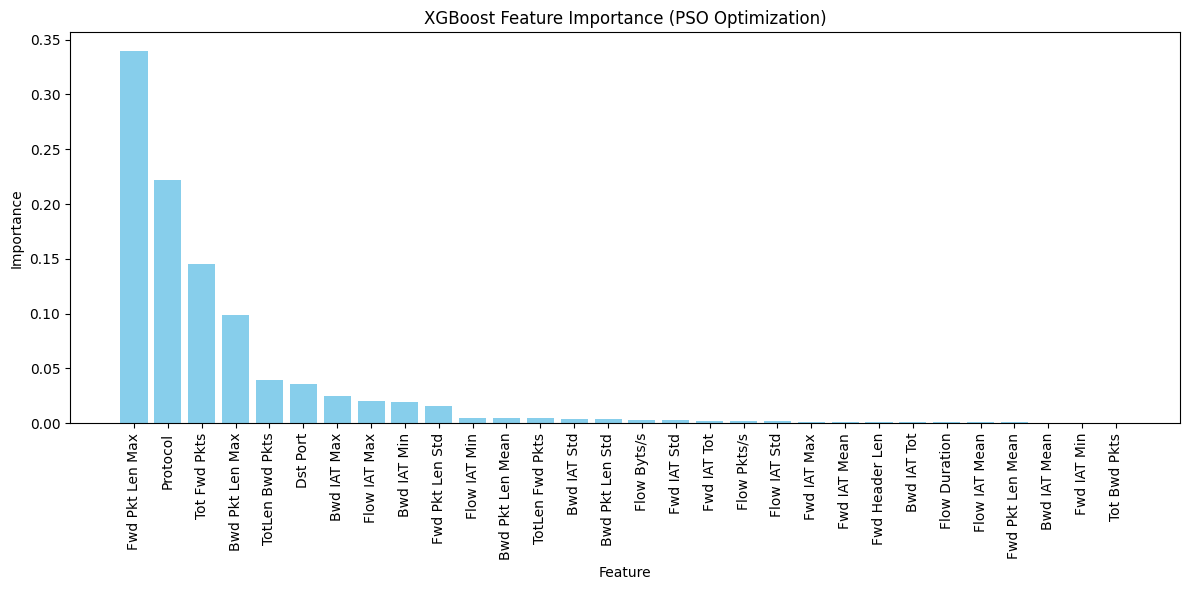


📊 Top 10 Feature Importances:
 1. Fwd Pkt Len Max - 0.3398
 2. Protocol - 0.2219
 3. Tot Fwd Pkts - 0.1451
 4. Bwd Pkt Len Max - 0.0989
 5. TotLen Bwd Pkts - 0.0391
 6. Dst Port - 0.0357
 7. Bwd IAT Max - 0.0244
 8. Flow IAT Max - 0.0205
 9. Bwd IAT Min - 0.0193
 10. Fwd Pkt Len Std - 0.0152


In [11]:
# ========================================
# FEATURE IMPORTANCE ANALYSIS (PSO)
# ========================================

if 'XGBoost' in trained_models:
    model = trained_models['XGBoost']
    feature_importances = model.feature_importances_
    
    # Trier les features par importance
    sorted_idx = np.argsort(feature_importances)[::-1]
    sorted_importances = feature_importances[sorted_idx]
    feature_names = X_full.columns[sorted_idx]
    
    # Plot
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(sorted_importances)), sorted_importances, color='skyblue')
    plt.xticks(range(len(sorted_importances)), feature_names, rotation=90)
    plt.title("XGBoost Feature Importance (PSO Optimization)")
    plt.ylabel("Importance")
    plt.xlabel("Feature")
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_MODEL_DIR, 'feature_importance_pso.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n📊 Top 10 Feature Importances:")
    for i in range(10):
        print(f" {i+1}. {feature_names[i]} - {sorted_importances[i]:.4f}")
